## Non-Parametric Density Estimation

Parametric estimation assumes the data follows a known shape, like normal, then fits that shape using just a couple of numbers (mean and standard deviation). We just saw this doesn't always work well, `total_bill` turned out to be right skewed, not symmetric, so a normal curve forced onto it gave a noticeably wrong probability estimate.

**Non-parametric estimation** takes a different approach. Instead of assuming any fixed shape in advance, it looks directly at where the actual data points are and builds a curve from that, letting the real shape emerge naturally, however irregular it may be.

The most common non-parametric method is called **Kernel Density Estimation (KDE)**.

## Building KDE Manually

Let's build a simple KDE by hand, using just a few data points first, so the "placing bumps and adding them up" idea is easy to see clearly, before applying it to the full dataset.

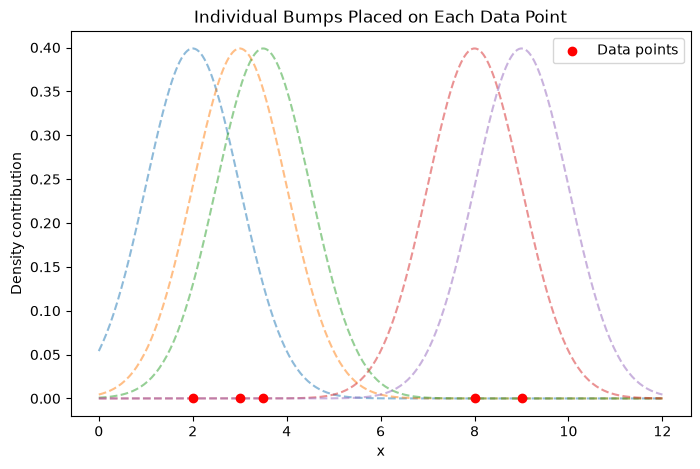

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# a few sample points to keep things simple
points = np.array([2, 3, 3.5, 8, 9])

# where we want to evaluate the density
x_range = np.linspace(0, 12, 300)

# bandwidth controls how wide each bump is
bandwidth = 1.0

def gaussian_kernel(x, center, bandwidth):
    return (1 / (bandwidth * np.sqrt(2 * np.pi))) * np.exp(-((x - center) ** 2) / (2 * bandwidth ** 2))

# plot each individual bump
plt.figure(figsize=(8, 5))
for point in points:
    bump = gaussian_kernel(x_range, point, bandwidth)
    plt.plot(x_range, bump, linestyle='--', alpha=0.5)

plt.scatter(points, np.zeros_like(points), color='red', zorder=5, label='Data points')
plt.title('Individual Bumps Placed on Each Data Point')
plt.xlabel('x')
plt.ylabel('Density contribution')
plt.legend()
plt.show()

## Explaining the Manual KDE Code

Here's what's actually happening in that code, step by step.

**The data points:** we picked 5 simple numbers (2, 3, 3.5, 8, 9) instead of a full dataset, just so the bumps are easy to see without clutter.

**The x_range:** this is just a long list of evenly spaced x values from 0 to 12, think of it as "every point on the x axis we want to check the density at." We need this because we're drawing a smooth curve, not just computing one single number.

**The gaussian_kernel function:** this is the actual bump. It's the exact same normal distribution formula from before, but now `center` plays the role μ used to play. Instead of centering the bell curve on the overall mean of the dataset, we center a small bell curve directly on top of **one single data point**. So this function answers: "if I place a tiny bell curve exactly on this one data point, how tall would that bump be at any given x?"

**The bandwidth:** this controls how wide each bump is. A bigger bandwidth spreads the bump out more, making it wider and flatter. A smaller bandwidth keeps the bump narrow and tall. We'll explore how this choice affects the final curve shortly.

**The loop:** for every single data point, we calculate its bump's height across the entire x_range, then plot it as a dashed line. This is why you see 5 separate dashed curves, one per data point, each centered exactly where that point sits.

**The red dots:** these just mark where the actual data points are on the x axis, placed at height 0, so you can visually confirm each dashed bump is centered correctly on its matching point.

Right now, we're only looking at the bumps individually, side by side. The real KDE curve comes from **adding all these bumps together** into one single combined curve, which is the next step.

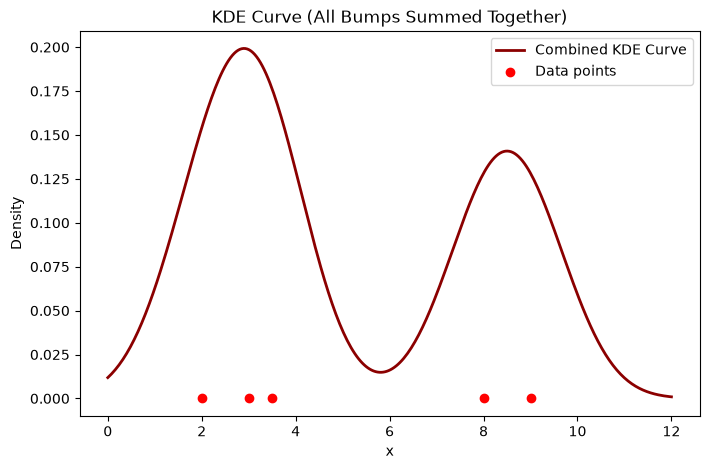

In [33]:
# add up all the bumps at every x to get the real KDE curve
total_density = np.zeros_like(x_range)

for point in points:
    total_density += gaussian_kernel(x_range, point, bandwidth)

# normalize so it behaves like a real density (area under curve = 1)
total_density = total_density / len(points)

plt.figure(figsize=(8, 5))
plt.plot(x_range, total_density, color='darkred', linewidth=2, label='Combined KDE Curve')
plt.scatter(points, np.zeros_like(points), color='red', zorder=5, label='Data points')
plt.title('KDE Curve (All Bumps Summed Together)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

## Summing the Bumps Together

This is the actual KDE curve. Instead of looking at each point's bump separately, we add all 5 bumps together at every x value.

Where points are close together, like 2, 3, and 3.5, their bumps overlap and stack up, creating a taller peak in that area. Where points are far apart or isolated, like 8 and 9 being far from the first group, the bumps don't overlap much with the others, so that region gets its own smaller, separate bump.

We also divided by the number of points at the end. This keeps the total area under the curve equal to 1, just like any valid density function must satisfy.

This is the real difference from parametric estimation. Instead of assuming one overall shape (like a single symmetric bell curve) and compressing the whole dataset into just two numbers (mean and std), KDE builds the curve directly from where the actual points are, so it can naturally show multiple peaks, gaps, or skew, whatever the real data looks like.

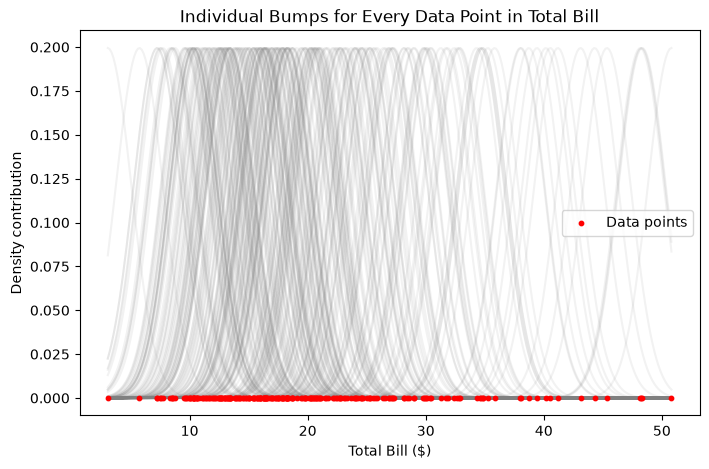

In [39]:
import seaborn as sns

df = sns.load_dataset("tips")
real_points = df['total_bill'].values

x_range_real = np.linspace(real_points.min(), real_points.max(), 300)
bandwidth = 2.0

plt.figure(figsize=(8, 5))
for point in real_points:
    bump = gaussian_kernel(x_range_real, point, bandwidth)
    plt.plot(x_range_real, bump, color='gray', alpha=0.1)

plt.scatter(real_points, np.zeros_like(real_points), color='red', s=10, zorder=5, label='Data points')
plt.title('Individual Bumps for Every Data Point in Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Density contribution')
plt.legend()
plt.show()

## Reading the Bump Plot

In this plot, you can see hundreds of individual bell curves overlapping, one for every real bill amount. On the left side, around 10 to 20, bumps are packed tightly together, overlapping heavily. On the right side, past 40, bumps are far more spread out and isolated.

This difference in crowding is exactly what will decide the shape of the final combined curve.

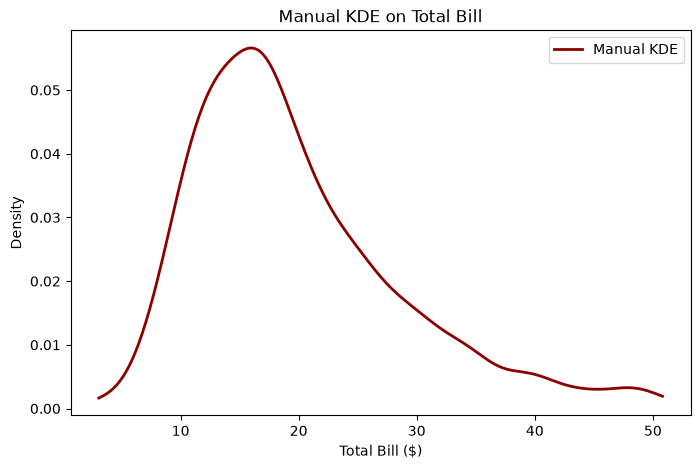

In [48]:
total_density_real = np.zeros_like(x_range_real)

for point in real_points:
    total_density_real += gaussian_kernel(x_range_real, point, bandwidth)

total_density_real = total_density_real / len(real_points)

plt.figure(figsize=(8, 5))
plt.plot(x_range_real, total_density_real, color='darkred', linewidth=2, label='Manual KDE')
plt.title('Manual KDE on Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Reading the Combined Curve

Where bumps overlap a lot, like around 15 to 20, they stack up and add together, producing a tall peak in the final curve. Where bumps are sparse and scattered, like near 40 to 50, there's little overlap, so the combined curve stays low and flat.

This is the entire mechanism behind KDE in one picture. The final smooth curve isn't some separate calculation, it's literally just the sum of all those overlapping bumps, measured at every x value. More overlapping bumps means more density, fewer or spread out bumps means less density.

This also naturally produces the right skewed shape we expected, a sharp rise where most bills cluster, followed by a long, gentle decline where larger bills become increasingly rare.

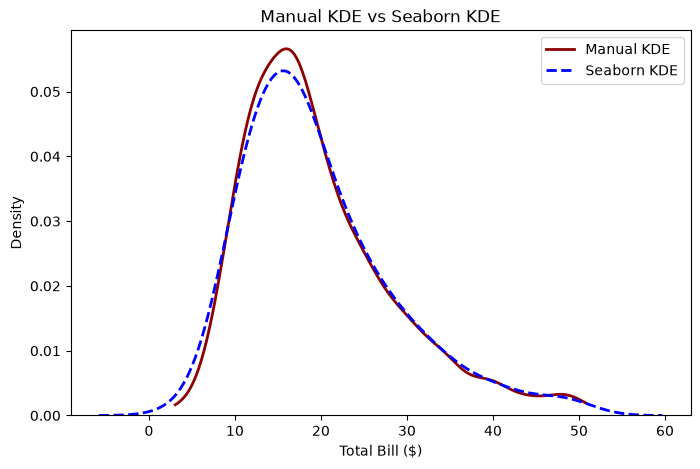

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(x_range_real, total_density_real, color='darkred', linewidth=2, label='Manual KDE')
sns.kdeplot(real_points, color='blue', linestyle='--', linewidth=2, label='Seaborn KDE')
plt.title('Manual KDE vs Seaborn KDE')
plt.xlabel('Total Bill ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Comparing Manual KDE Against Seaborn

Our manual curve and seaborn's built-in curve line up closely, both show the same overall shape, the same peak location around 15 to 20, and the same long right tail.

There are small differences though. Seaborn's curve is slightly wider and extends a bit further on both ends, even dipping slightly below zero on the left. This happens because seaborn automatically picks its own bandwidth, usually a bit larger than the 2.0 we chose manually, which smooths the curve out a little more.

This confirms our manual KDE is doing exactly what it should. It's not a separate or wrong method, it's the same underlying idea, summing overlapping bumps, just with a bandwidth we picked ourselves instead of one calculated automatically. This also shows that bandwidth is a real choice that affects the final shape, a detail worth exploring next.